# Notebook 06 — Ensemble Experiments

**Objective:** Test multiple ensemble strategies combining the active Huber baseline with XGBoost and LightGBM quantile models. Only promote an ensemble if it improves production MAPE by ≥ 0.2% absolute and passes all diagnostics.

## Ensemble Methods
1. **Simple average** — equal-weight blend
2. **Weighted average** — grid-search over weights
3. **Robust average** — trimmed-mean ensemble
4. **Stacking meta-model** — Ridge on OOF base predictions

## Promotion Criteria
- MAPE improvement ≥ 0.2% absolute over best single model
- No degradation in R², Within-10%, or interval coverage

In [1]:
## 1) Imports & Configuration
import sys, json, datetime, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import joblib
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-dark')

In [12]:
def find_ml_root(start=None):
    start = (start or Path.cwd()).resolve()
    for c in (start, *start.parents):
        if (c / 'app' / 'core' / 'config.py').exists():
            return c
    raise FileNotFoundError('Cannot find ml-service root')


def sparse_to_dense(X):
    if hasattr(X, 'toarray'):
        return X.toarray()
    return X

ML_ROOT = find_ml_root()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from app.core.config import settings
from app.core.model_registry import (
    load_registry, get_active_model_info, get_active_model_path,
    model_pickles_dir, model_plots_dir, save_model_metadata,
    register_model, promote_active_model,
)

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
QUANTILES = {'lower': 0.05, 'median': 0.50, 'upper': 0.95}
MODEL_VERSION = 'v1.1.0'

XGB_BEST_PARAMS = {
    'learning_rate': 0.015490483286740053,
    'max_depth': 11,
    'min_child_weight': 4,
    'subsample': 0.6622077411666858,
    'colsample_bytree': 0.8536659127023519,
    'reg_alpha': 0.085522303812033,
    'reg_lambda': 1.3969605300880791e-07,
    'gamma': 0.447036756545783,
    'max_bin': 512,
}
LGBM_BEST_PARAMS = {
    'learning_rate': 0.027681271280960946,
    'num_leaves': 62,
    'max_depth': 10,
    'min_child_samples': 12,
    'subsample': 0.715216053848345,
    'colsample_bytree': 0.5431488908733526,
    'reg_alpha': 0.49247701388255255,
    'reg_lambda': 1.7238989341211074e-05,
    'min_split_gain': 0.02774152144413644,
}

OUT_DIR  = model_pickles_dir()
PLOT_DIR = model_plots_dir('06_ensemble_experiments')
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Artifact dir:', OUT_DIR)
print('Plot dir:    ', PLOT_DIR)

Artifact dir: /home/mo-seif/Documents/GP/ml-service/models/pickles
Plot dir:     /home/mo-seif/Documents/GP/ml-service/models/plots_06_ensemble_experiments


## 2) Load Data & Preprocessing
Same feature set as notebook 05 (no `model_family`, no `car_age`).

In [4]:
df_raw = settings.load_data('processed').copy()
print('Dataset shape:', df_raw.shape)
display(df_raw.head(3))

Dataset shape: (20214, 18)


,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment,price_egp,price_egp_log
0,BYD,F3,2024,2,Manual,petrol,4410.0,2205.000000,Giza,1500,109,Sedan,FWD,5,chinese,family,630000,13.353475
1,BYD,F3,2025,1,Manual,petrol,33033.0,33033.000000,Nasr City,1500,109,Sedan,FWD,5,chinese,family,610000,13.321214
2,Subaru,Impreza,2009,17,Manual,petrol,98000.0,5764.705882,Maadi,1498,107,Sedan,AWD,5,japanese,family,410000,12.923912


In [5]:
DROP_COLS  = {'price_egp', 'price_egp_log', 'car_age'}
CAT_COLS = ['make', 'model', 'transmission', 'fuel', 'location',
            'body_type', 'drivetrain', 'brand_origin', 'car_segment']
NUM_COLS = [c for c in df_raw.columns if c not in DROP_COLS and c not in CAT_COLS]
FEATURE_COLS = NUM_COLS + CAT_COLS

MIN_ROWS_PER_MODEL = 5
_model_counts = df_raw.groupby(['make', 'model']).size().reset_index(name='n')
_rare_models = _model_counts.loc[_model_counts['n'] < MIN_ROWS_PER_MODEL]
RARE_MODEL_SET = set(zip(_rare_models['make'], _rare_models['model']))

def apply_rare_grouping(df):
    df = df.copy()
    if 'model' in df.columns and 'make' in df.columns:
        mask = [(m, mo) in RARE_MODEL_SET for m, mo in zip(df['make'], df['model'])]
        df.loc[mask, 'model'] = df.loc[mask, 'make'].apply(lambda x: f'OTHER_{x}')
    return df

df_raw = apply_rare_grouping(df_raw)
print(f'Features: {len(FEATURE_COLS)} ({len(NUM_COLS)} num + {len(CAT_COLS)} cat)')

Features: 15 (6 num + 9 cat)


In [6]:
def make_lgbm_frame(df):
    X = df[FEATURE_COLS].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype('category')
    return X

label_encoders = {}
df_xgb_encoded = df_raw[FEATURE_COLS].copy()
for c in CAT_COLS:
    le = LabelEncoder()
    df_xgb_encoded[c] = le.fit_transform(df_xgb_encoded[c].fillna('__MISSING__').astype(str))
    label_encoders[c] = le

X_lgbm_all = make_lgbm_frame(df_raw)
X_xgb_all  = df_xgb_encoded.copy()
print('Feature matrices ready:', X_lgbm_all.shape, X_xgb_all.shape)

Feature matrices ready: (20214, 15) (20214, 15)


## 3) Train / Load Base Models

In [7]:
def _build_price_bins(price, desired_bins=10):
    s = pd.to_numeric(price, errors='coerce').fillna(price.median())
    for q in [desired_bins, 8, 6, 5, 4, 3]:
        try:
            b = pd.qcut(s, q=q, duplicates='drop')
        except Exception:
            continue
        codes = b.cat.codes.astype(int)
        rare = codes.value_counts()[codes.value_counts() < 2].index
        codes = codes.where(~codes.isin(rare), -1)
        if codes.value_counts().min() >= 2:
            return codes
    return pd.Series(np.zeros(len(s), dtype=int), index=price.index)

idx_all = df_raw.index.to_numpy()
strat_price = _build_price_bins(df_raw['price_egp'])
tr_idx, te_idx = train_test_split(idx_all, test_size=TEST_SIZE,
                                  random_state=RANDOM_STATE, stratify=strat_price)
print(f'Train: {len(tr_idx):,}  Test: {len(te_idx):,}')

Train: 16,171  Test: 4,043


In [8]:
xgb_models = None
xgb_path = OUT_DIR / 'xgb_quantile_models.joblib'
xgb_registry_path = None

registry_info = get_active_model_info()
if registry_info is not None:
    xgb_registry_path = registry_info.get('pkl_path') or registry_info.get('artifacts', {}).get('model_pkl')

xgb_candidates = [
    xgb_registry_path,
    xgb_path,
    ML_ROOT / 'models' / 'pickles' / 'xgb_quantile_models.joblib',
]
for candidate in xgb_candidates:
    if candidate is None:
        continue
    candidate_path = Path(candidate)
    if not candidate_path.is_absolute():
        candidate_path = (ML_ROOT / candidate_path).resolve()
    if candidate_path.exists():
        xgb_path = candidate_path
        xgb_models = joblib.load(xgb_path)
        print(f'Loaded XGBoost models: {list(xgb_models.keys())} from {xgb_path}')
        break

if xgb_models is None:
    print('XGBoost quantile models were not found. They will be retrained below with the stored best hyperparameters.')

lgbm_models = None
lgbm_path = OUT_DIR / 'lgbm_quantile_models.joblib'
lgbm_candidates = [
    lgbm_path,
    ML_ROOT / 'models' / 'pickles' / 'lgbm_quantile_models.joblib',
]
for candidate in lgbm_candidates:
    candidate_path = Path(candidate)
    if not candidate_path.is_absolute():
        candidate_path = (ML_ROOT / candidate_path).resolve()
    if candidate_path.exists():
        lgbm_path = candidate_path
        lgbm_models = joblib.load(lgbm_path)
        print(f'Loaded LightGBM models: {list(lgbm_models.keys())} from {lgbm_path}')
        break

if lgbm_models is None:
    print('LightGBM quantile models were not found. They will be retrained below with the stored best hyperparameters.')

Loaded XGBoost models: ['lower', 'median', 'upper'] from /home/mo-seif/Documents/GP/ml-service/models/pickles/xgb_quantile_models.joblib
LightGBM quantile models were not found. They will be retrained below with the stored best hyperparameters.


In [24]:
lgbm_price_marker = lgbm_path.with_suffix('.price_target.ok')
if lgbm_models is not None and not lgbm_price_marker.exists():
    lgbm_models = None

if lgbm_models is None:
    X_tr = X_lgbm_all.loc[tr_idx]
    y_tr = df_raw.loc[tr_idx, 'price_egp']
    X_te = X_lgbm_all.loc[te_idx]
    y_te = df_raw.loc[te_idx, 'price_egp']
    dt_lgbm = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CAT_COLS, free_raw_data=False)
    dv_lgbm = lgb.Dataset(X_te, label=y_te, categorical_feature=CAT_COLS, free_raw_data=False, reference=dt_lgbm)
    lgbm_models = {}
    for q_name, q_val in QUANTILES.items():
        params = {
            **LGBM_BEST_PARAMS,
            'objective': 'quantile',
            'alpha': q_val,
            'metric': 'quantile',
            'verbosity': -1,
            'n_jobs': -1,
            'seed': RANDOM_STATE,
            'subsample_freq': 1,
            'feature_pre_filter': False,
        }
        lgbm_models[q_name] = lgb.train(
            params,
            dt_lgbm,
            num_boost_round=2000,
            valid_sets=[dv_lgbm],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
        )
    joblib.dump(lgbm_models, lgbm_path)
    lgbm_price_marker.write_text('trained_on_price_egp\n', encoding='utf-8')
    print(f'Trained and saved LightGBM → {lgbm_path}')
else:
    print(f'Using pre-trained LightGBM models from {lgbm_path}')

Trained and saved LightGBM → /home/mo-seif/Documents/GP/ml-service/models/pickles/lgbm_quantile_models.joblib


In [21]:
if xgb_models is None:
    X_tr = X_xgb_all.loc[tr_idx]
    y_tr = df_raw.loc[tr_idx, 'price_egp']
    X_te = X_xgb_all.loc[te_idx]
    y_te = df_raw.loc[te_idx, 'price_egp']
    dm_tr = xgb.DMatrix(X_tr, label=y_tr)
    dm_te = xgb.DMatrix(X_te, label=y_te)
    xgb_models = {}
    for q_name, q_val in QUANTILES.items():
        params = {
            **XGB_BEST_PARAMS,
            'objective': 'reg:quantileerror',
            'quantile_alpha': q_val,
            'eval_metric': 'mae',
            'tree_method': 'hist',
            'seed': RANDOM_STATE,
        }
        xgb_models[q_name] = xgb.train(
            params,
            dm_tr,
            num_boost_round=2000,
            evals=[(dm_te, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False,
        )
    joblib.dump(xgb_models, xgb_path)
    print(f'Trained and saved XGBoost → {xgb_path}')
else:
    print(f'Using pre-trained XGBoost models from {xgb_path}')

Using pre-trained XGBoost models from /home/mo-seif/Documents/GP/ml-service/models/pickles/xgb_quantile_models.joblib


In [23]:
huber_model = None
huber_path = None
huber_candidates = [
    ML_ROOT / 'models' / 'pickles' / 'Baseline1__huberregressortuned.pkl',
    OUT_DIR / 'Baseline1__huberregressortuned.pkl',
]
for candidate in huber_candidates:
    candidate_path = Path(candidate)
    if not candidate_path.is_absolute():
        candidate_path = (ML_ROOT / candidate_path).resolve()
    if candidate_path.exists():
        huber_path = candidate_path
        try:
            huber_model = joblib.load(huber_path)
            print(f'Loaded Huber baseline: {huber_path}')
        except Exception as exc:
            print(f'Huber artifact exists but could not be loaded: {exc}')
            huber_model = None
        break

if huber_model is None:
    print('Huber baseline artifact not found. Ensemble will continue without Huber.')

Loaded Huber baseline: /home/mo-seif/Documents/GP/ml-service/models/pickles/Baseline1__huberregressortuned.pkl


## 4) Generate Base Predictions on Test Set

In [26]:
y_test = df_raw.loc[te_idx, 'price_egp'].to_numpy()
y_test_log = df_raw.loc[te_idx, 'price_egp_log'].to_numpy()
dm_test_xgb = xgb.DMatrix(X_xgb_all.loc[te_idx])
base_pred_maps = {}
median_preds_list = []
quantile_lower_list = []
quantile_upper_list = []
median_model_names = []
quantile_model_names = []

xgb_preds_egp = None
if xgb_models is not None:
    xgb_preds = {q: np.asarray(m.predict(dm_test_xgb)) for q, m in xgb_models.items()}
    xgb_preds_egp = xgb_preds
    base_pred_maps['XGBoost'] = xgb_preds_egp
    median_preds_list.append(xgb_preds_egp['median'])
    quantile_lower_list.append(xgb_preds_egp['lower'])
    quantile_upper_list.append(xgb_preds_egp['upper'])
    median_model_names.append('XGBoost')
    quantile_model_names.append('XGBoost')

lgbm_preds_egp = None
if lgbm_models is not None:
    lgbm_preds = {q: np.asarray(m.predict(X_lgbm_all.loc[te_idx])) for q, m in lgbm_models.items()}
    lgbm_preds_egp = lgbm_preds
    base_pred_maps['LightGBM'] = lgbm_preds_egp
    median_preds_list.append(lgbm_preds_egp['median'])
    quantile_lower_list.append(lgbm_preds_egp['lower'])
    quantile_upper_list.append(lgbm_preds_egp['upper'])
    median_model_names.append('LightGBM')
    quantile_model_names.append('LightGBM')

huber_preds = None
if huber_model is not None:
    try:
        huber_input_cols = [c for c in (FEATURE_COLS + ['car_age']) if c in df_raw.columns]
        huber_raw = np.asarray(huber_model.predict(df_raw.loc[te_idx, huber_input_cols]))
        huber_preds = np.exp(huber_raw)
        base_pred_maps['Huber'] = {'median': huber_preds}
        median_preds_list.append(huber_preds)
        median_model_names.append('Huber')
    except Exception as exc:
        print(f'Huber prediction failed: {exc}')

if not median_preds_list:
    raise RuntimeError('No pre-trained base model predictions are available.')

print('Base predictions generated from pre-trained artifacts.')
for model_name, pred_map in base_pred_maps.items():
    print(f'  {model_name}: median [{pred_map["median"].min():.0f}, {pred_map["median"].max():.0f}]')
    if 'lower' in pred_map and 'upper' in pred_map:
        print(f'           interval [{pred_map["lower"].min():.0f}, {pred_map["upper"].max():.0f}]')

print(f'Available median models: {median_model_names}')
print(f'Available quantile models: {quantile_model_names}')

Base predictions generated from pre-trained artifacts.
  XGBoost: median [31954, 16186425]
           interval [25287, 17332702]
  LightGBM: median [19351, 15485235]
           interval [19529, 17807296]
  Huber: median [25624, 16262775]
Available median models: ['XGBoost', 'LightGBM', 'Huber']
Available quantile models: ['XGBoost', 'LightGBM']


## 5) Metric Helpers

In [15]:
def compute_metrics(y_true, y_pred, is_log=False):
    if is_log: y_true, y_pred = np.exp(y_true), np.exp(y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    eps = 1e-9; denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)
    w10 = float(np.mean(np.abs((y_true - y_pred) / denom) <= 0.10) * 100)
    w15 = float(np.mean(np.abs((y_true - y_pred) / denom) <= 0.15) * 100)
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE_pct=mape, Within_10pct=w10, Within_15pct=w15)

def compute_ci_metrics(y_true, y_lo, y_med, y_hi):
    y_lo = np.minimum(np.asarray(y_lo,float), np.asarray(y_med,float))
    y_hi = np.maximum(np.asarray(y_hi,float), np.asarray(y_med,float))
    coverage = float(np.mean((y_true >= y_lo) & (y_true <= y_hi)) * 100)
    eps = 1e-9; rel_width = (y_hi - y_lo) / np.maximum(np.abs(np.asarray(y_med,float)), eps)
    mean_w = float(np.mean(rel_width) * 100)
    return dict(Coverage_80_pct=coverage, Mean_width_pct=mean_w)

print('Metric helpers ready.')

Metric helpers ready.


## 6) Ensemble Method 1 — Simple Average

In [27]:
results = []
n_base = len(median_preds_list)

def simple_average(preds_list):
    return np.mean(preds_list, axis=0)

ens_simple_med = simple_average(median_preds_list)
ens_simple_lo = simple_average(quantile_lower_list) if quantile_lower_list else ens_simple_med
ens_simple_hi = simple_average(quantile_upper_list) if quantile_upper_list else ens_simple_med
m = compute_metrics(y_test, ens_simple_med)
ci = compute_ci_metrics(y_test, ens_simple_lo, ens_simple_med, ens_simple_hi)
results.append({'method': 'Simple Average', **m, **ci})
print('Simple Average:')
for k, v in m.items():
    print(f'  {k}: {v:.3f}')

Simple Average:
  MAE: 136333.536
  RMSE: 467745.699
  R2: 0.891
  MAPE_pct: 12.926
  Within_10pct: 60.524
  Within_15pct: 75.810


## 7) Ensemble Method 2 — Weighted Average (Grid Search)

In [28]:
best_mape = float('inf')
best_weights = None
best_pred = None
if n_base == 1:
    weight_grid = [(1.0,)]
elif n_base == 2:
    weight_grid = [(w, round(1.0 - w, 10)) for w in np.arange(0.0, 1.01, 0.1)]
elif n_base == 3:
    weight_grid = []
    for w1 in np.arange(0.0, 1.01, 0.1):
        for w2 in np.arange(0.0, 1.01 - w1, 0.1):
            w3 = round(1.0 - w1 - w2, 10)
            if w3 >= -1e-9:
                weight_grid.append((round(w1, 10), round(w2, 10), w3))
else:
    weight_grid = [tuple([1.0 / n_base] * n_base)]

for weights in weight_grid:
    pred = sum(w * p for w, p in zip(weights, median_preds_list))
    mape = float(np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), 1e-9))) * 100)
    if mape < best_mape:
        best_mape = mape
        best_weights = weights
        best_pred = pred

ens_weighted_med = best_pred
ens_weighted_lo = sum(w * p for w, p in zip(best_weights, quantile_lower_list)) if quantile_lower_list else ens_weighted_med
ens_weighted_hi = sum(w * p for w, p in zip(best_weights, quantile_upper_list)) if quantile_upper_list else ens_weighted_med
m = compute_metrics(y_test, ens_weighted_med)
ci = compute_ci_metrics(y_test, ens_weighted_lo, ens_weighted_med, ens_weighted_hi)
results.append({'method': 'Weighted Average', **m, **ci})
print(f'Weighted Average (weights: {best_weights}):')
for k, v in m.items():
    print(f'  {k}: {v:.3f}')

Weighted Average (weights: (np.float64(0.4), np.float64(0.4), np.float64(0.2))):
  MAE: 135489.869
  RMSE: 465000.145
  R2: 0.892
  MAPE_pct: 12.911
  Within_10pct: 60.673
  Within_15pct: 75.934


## 8) Ensemble Method 3 — Robust Average (Trimmed Mean)

In [29]:
def robust_average(preds_list, trim_fraction=0.2):
    preds_arr = np.array(preds_list)
    n_models = preds_arr.shape[0]
    n_trim = max(1, int(n_models * trim_fraction))
    sorted_preds = np.sort(preds_arr, axis=0)
    trimmed = sorted_preds[n_trim : n_models - n_trim]
    if trimmed.shape[0] == 0:
        return np.median(preds_arr, axis=0)
    return np.mean(trimmed, axis=0)

ens_robust_med = robust_average(median_preds_list)
ens_robust_lo = robust_average(quantile_lower_list) if quantile_lower_list else ens_robust_med
ens_robust_hi = robust_average(quantile_upper_list) if quantile_upper_list else ens_robust_med
m = compute_metrics(y_test, ens_robust_med)
ci = compute_ci_metrics(y_test, ens_robust_lo, ens_robust_med, ens_robust_hi)
results.append({'method': 'Robust Average', **m, **ci})
print('Robust Average:')
for k, v in m.items():
    print(f'  {k}: {v:.3f}')

Robust Average:
  MAE: 133592.676
  RMSE: 473138.304
  R2: 0.888
  MAPE_pct: 12.775
  Within_10pct: 61.266
  Within_15pct: 76.577


## 9) Ensemble Method 4 — Stacking Meta-Model (Ridge)

In [34]:
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
oof_preds = np.zeros((len(tr_idx), n_base))

for fold_i, (_, fold_te_pos) in enumerate(kf.split(tr_idx)):
    fold_te = tr_idx[fold_te_pos]
    if xgb_models is not None:
        xgb_col = median_model_names.index('XGBoost')
        oof_preds[fold_te_pos, xgb_col] = xgb_models['median'].predict(xgb.DMatrix(X_xgb_all.loc[fold_te]))
    if lgbm_models is not None:
        lgbm_col = median_model_names.index('LightGBM')
        oof_preds[fold_te_pos, lgbm_col] = lgbm_models['median'].predict(X_lgbm_all.loc[fold_te])
    if huber_model is not None and 'Huber' in median_model_names:
        huber_col = median_model_names.index('Huber')
        try:
            huber_input_cols = [c for c in (FEATURE_COLS + ['car_age']) if c in df_raw.columns]
            oof_preds[fold_te_pos, huber_col] = np.exp(huber_model.predict(df_raw.loc[fold_te, huber_input_cols]))
        except Exception:
            oof_preds[fold_te_pos, huber_col] = oof_preds[fold_te_pos, 0]
    print(f'  Fold {fold_i + 1}/{n_folds} done')

def build_stack_input(which: str) -> np.ndarray:
    cols = []
    for model_name in median_model_names:
        pred_map = base_pred_maps[model_name]
        cols.append(pred_map.get(which, pred_map['median']))
    return np.column_stack(cols)

y_train_egp = df_raw.loc[tr_idx, 'price_egp'].to_numpy()
meta_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
meta_model.fit(oof_preds, y_train_egp)
test_base = build_stack_input('median')
ens_stack_med = meta_model.predict(test_base)
ens_stack_lo = meta_model.predict(build_stack_input('lower'))
ens_stack_hi = meta_model.predict(build_stack_input('upper'))
m = compute_metrics(y_test, ens_stack_med)
ci = compute_ci_metrics(y_test, ens_stack_lo, ens_stack_med, ens_stack_hi)
results.append({'method': 'Stacking (Ridge)', **m, **ci})
print('Stacking (Ridge):')
for k, v in m.items():
    print(f'  {k}: {v:.3f}')
print(f'  Coefficients: {meta_model.coef_}, intercept: {meta_model.intercept_:.2f}')

  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
Stacking (Ridge):
  MAE: 142821.454
  RMSE: 470300.757
  R2: 0.890
  MAPE_pct: 14.166
  Within_10pct: 57.284
  Within_15pct: 72.471
  Coefficients: [ 1.31906668 -0.30602109  0.02023352], intercept: -12826.01


## 10) Comparison Table & Promotion Decision

In [41]:
if xgb_preds_egp is not None:
    xgb_single_metrics = compute_metrics(y_test, xgb_preds_egp['median'])
    xgb_single_ci = compute_ci_metrics(y_test, xgb_preds_egp['lower'], xgb_preds_egp['median'], xgb_preds_egp['upper'])
    results.append({'method': 'XGBoost (single)', **xgb_single_metrics, **xgb_single_ci})

if lgbm_preds_egp is not None:
    lgbm_single_metrics = compute_metrics(y_test, lgbm_preds_egp['median'])
    lgbm_single_ci = compute_ci_metrics(y_test, lgbm_preds_egp['lower'], lgbm_preds_egp['median'], lgbm_preds_egp['upper'])
    results.append({'method': 'LightGBM (single)', **lgbm_single_metrics, **lgbm_single_ci})

if huber_preds is not None:
    results.append({'method': 'Huber (single)', **compute_metrics(y_test, huber_preds), 'Coverage_80_pct': np.nan, 'Mean_width_pct': np.nan})

df_results = pd.DataFrame(results).drop_duplicates(subset='method', keep='last').set_index('method')
display(df_results.round(3))

,MAE,RMSE,R2,MAPE_pct,Within_10pct,Within_15pct,Coverage_80_pct,Mean_width_pct
method,,,,,,,,
Simple Average,136333.536,467745.699,0.891,12.926,60.524,75.810,86.817,76.549
Weighted Average,135489.869,465000.145,0.892,12.911,60.673,75.934,65.372,64.073
Robust Average,133592.676,473138.304,0.888,12.775,61.266,76.577,86.792,77.266
Stacking (Ridge),142821.454,470300.757,0.890,14.166,57.284,72.471,87.460,96.353
XGBoost (single),138277.469,463948.515,0.893,13.534,59.659,74.499,87.707,86.452
LightGBM (single),141290.665,482249.427,0.884,13.401,59.288,74.920,80.633,68.486
Huber (single),159668.237,522561.664,0.864,14.624,54.588,70.245,NaN,NaN


In [42]:
MAPE_THRESHOLD = 0.2
single_rows = []
if xgb_preds_egp is not None:
    single_rows.append(('XGBoost (single)', compute_metrics(y_test, xgb_preds_egp['median'])))
if lgbm_preds_egp is not None:
    single_rows.append(('LightGBM (single)', compute_metrics(y_test, lgbm_preds_egp['median'])))
if huber_preds is not None:
    single_rows.append(('Huber (single)', compute_metrics(y_test, huber_preds)))

if not single_rows:
    raise RuntimeError('No single-model metrics are available for promotion comparison.')

single_mape = min(metrics['MAPE_pct'] for _, metrics in single_rows)
ensemble_mask = df_results.index.to_series().str.contains('Average|Stacking', case=False, regex=True)
if ensemble_mask.any():
    best_ens = df_results.loc[ensemble_mask, 'MAPE_pct'].idxmin()
    best_ens_mape = df_results.loc[best_ens, 'MAPE_pct']
    improvement = single_mape - best_ens_mape
    print(f'Best single MAPE:  {single_mape:.3f}%')
    print(f'Best ensemble MAPE: {best_ens_mape:.3f}% ({best_ens})')
    print(f'Improvement: {improvement:.3f}% (threshold: {MAPE_THRESHOLD}%)')
    if improvement >= MAPE_THRESHOLD:
        best_r2 = max(metrics['R2'] for _, metrics in single_rows)
        best_w10 = max(metrics['Within_10pct'] for _, metrics in single_rows)
        ens_r2 = df_results.loc[best_ens, 'R2']
        ens_w10 = df_results.loc[best_ens, 'Within_10pct']
        if ens_r2 >= best_r2 - 0.005 and ens_w10 >= best_w10 - 0.5:
            PROMOTE = True
            print(f'\n✓ PASSES ALL CHECKS → Promote "{best_ens}"')
        else:
            PROMOTE = False
            print('\n✗ Fails R2/W10 check')
    else:
        PROMOTE = False
        print(f'\n✗ Improvement {improvement:.3f}% < threshold → Do not promote')
else:
    PROMOTE = False
    print('No ensemble rows found; keeping the current single model.')

print(f'Final: {"PROMOTE" if PROMOTE else "KEEP SINGLE MODEL"}')

Best single MAPE:  13.401%
Best ensemble MAPE: 12.775% (Robust Average)
Improvement: 0.626% (threshold: 0.2%)

✓ PASSES ALL CHECKS → Promote "Robust Average"
Final: PROMOTE


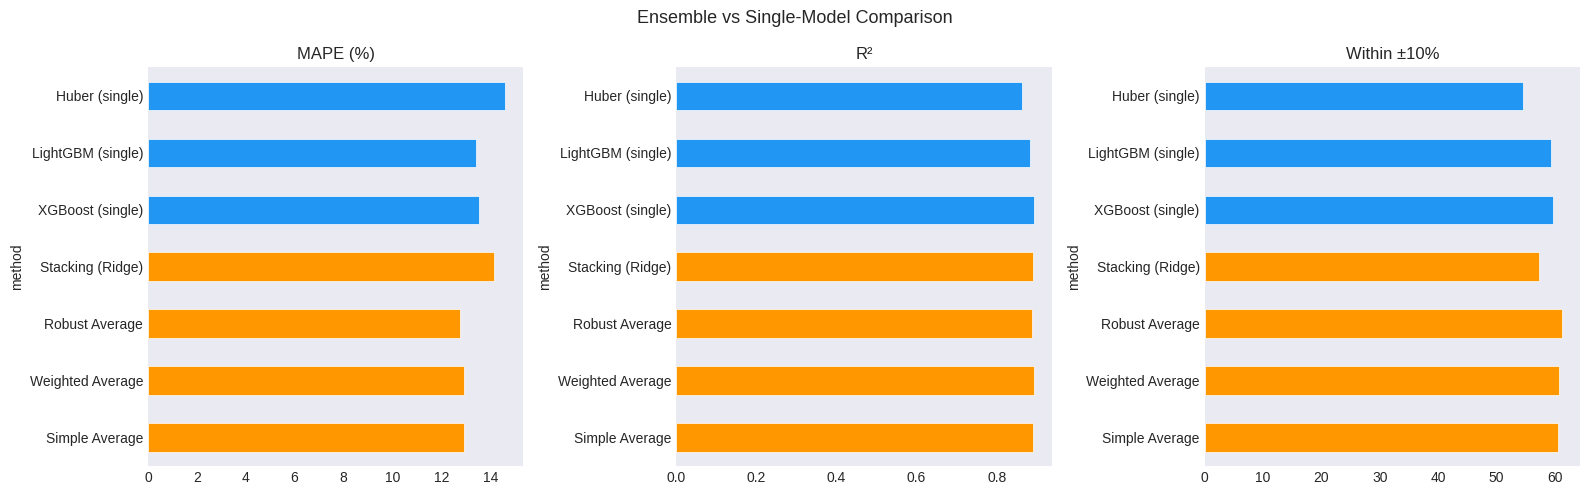

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in [(axes[0],'MAPE_pct','MAPE (%)'),(axes[1],'R2','R²'),(axes[2],'Within_10pct','Within ±10%')]:
    vals = df_results[metric].dropna()
    colors = ['#2196F3' if 'single' in idx.lower() or 'huber' in idx.lower() else '#FF9800' for idx in vals.index]
    vals.plot.barh(ax=ax, color=colors, edgecolor='white', lw=0.5)
    ax.set_title(title); ax.set_xlabel('')
plt.suptitle('Ensemble vs Single-Model Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ensemble_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 11) Per-Brand & Per-Price-Tier Diagnostics

In [38]:
df_test = df_raw.loc[te_idx].copy()
if xgb_preds_egp is not None:
    df_test['pred_single'] = xgb_preds_egp['median']
elif lgbm_preds_egp is not None:
    df_test['pred_single'] = lgbm_preds_egp['median']
else:
    df_test['pred_single'] = huber_preds

df_test['pred_ensemble'] = ens_weighted_med
brand_mape = []
for brand, grp in df_test.groupby('make'):
    if len(grp) < 10:
        continue
    ms = np.mean(np.abs((grp['price_egp'] - grp['pred_single']) / np.maximum(grp['price_egp'], 1e-9))) * 100
    me = np.mean(np.abs((grp['price_egp'] - grp['pred_ensemble']) / np.maximum(grp['price_egp'], 1e-9))) * 100
    brand_mape.append({'make': brand, 'n': len(grp), 'MAPE_single': ms, 'MAPE_ensemble': me, 'delta': ms - me})
df_brand = pd.DataFrame(brand_mape).sort_values('MAPE_single', ascending=False)
display(df_brand.head(15).round(2))
print(f'Brands improved: {(df_brand["delta"] > 0).sum()}/{len(df_brand)}, degraded (>0.5% worse): {(df_brand["delta"] < -0.5).sum()}/{len(df_brand)}')

,make,n,MAPE_single,MAPE_ensemble,delta
31,Porsche,24,30.76,33.73,-2.96
34,Seat,62,23.24,21.74,1.50
15,Honda,39,22.61,23.21,-0.60
37,SsangYong,15,19.81,19.38,0.43
5,Changan,24,19.46,16.45,3.01
22,Land Rover,44,19.40,19.14,0.26
7,Chevrolet,248,19.21,18.84,0.37
4,Brilliance,16,18.97,17.86,1.11
12,Ford,40,18.43,13.87,4.56
11,Fiat,165,18.36,16.92,1.44


Brands improved: 30/42, degraded (>0.5% worse): 5/42


In [39]:
price_bins = pd.qcut(df_test['price_egp'], q=5, duplicates='drop')
tier_mape = []
for tier, grp in df_test.groupby(price_bins, observed=True):
    ms = np.mean(np.abs((grp['price_egp']-grp['pred_single'])/np.maximum(grp['price_egp'],1e-9)))*100
    me = np.mean(np.abs((grp['price_egp']-grp['pred_ensemble'])/np.maximum(grp['price_egp'],1e-9)))*100
    tier_mape.append({'tier':str(tier),'n':len(grp),'MAPE_single':ms,'MAPE_ensemble':me})
display(pd.DataFrame(tier_mape).round(2))

,tier,n,MAPE_single,MAPE_ensemble
0,"(26999.999, 285000.0]",812,23.06,21.63
1,"(285000.0, 500000.0]",838,11.95,11.33
2,"(500000.0, 780000.0]",788,9.11,9.04
3,"(780000.0, 1450000.0]",799,11.13,10.43
4,"(1450000.0, 17000000.0]",806,12.29,12.00


## 12) Export Ensemble Artifacts (if promoted)

In [45]:
if PROMOTE:
    model_id = f'ensemble_{best_ens.replace(" ","_").lower()}_{MODEL_VERSION}'
    ensemble_artifact = {'method': best_ens, 'weights': best_weights if best_weights else None,
        'meta_model': meta_model if 'Stacking' in best_ens else None,
        'base_models': {'lgbm': str(OUT_DIR / 'lgbm_quantile_models.joblib'), 'xgb': str(OUT_DIR / 'xgb_quantile_models.joblib')},
        'feature_cols': FEATURE_COLS, 'cat_cols': CAT_COLS, 'num_cols': NUM_COLS}
    ens_path = OUT_DIR / f'ensemble_{MODEL_VERSION}.joblib'
    joblib.dump(ensemble_artifact, ens_path)
    print(f'Saved ensemble artifact → {ens_path}')
    ens_meta = {'version': MODEL_VERSION, 'model_id': model_id, 'framework': 'ensemble', 'ensemble_method': best_ens,
        'training_date': datetime.datetime.utcnow().isoformat() + 'Z', 'target_col': 'price_egp', 'is_log_target': False,
        'feature_cols': FEATURE_COLS, 'cat_cols': CAT_COLS, 'num_cols': NUM_COLS, 'quantiles': QUANTILES,
        'metrics': {k: float(v) for k, v in df_results.loc[best_ens].items() if not pd.isna(v)},
        'plot_dir': str(PLOT_DIR), 'source_notebook': '06_ensemble_experiments'}
    meta_path = save_model_metadata(ens_meta, filename=f'{model_id}.json')
    register_model(model_id, pkl_path=str(ens_path), meta_path=str(meta_path),
                   framework='ensemble', version=MODEL_VERSION,
                   metrics={k: float(v) for k, v in df_results.loc[best_ens][['MAPE_pct', 'R2']].items()})
    promote_active_model(model_id)
    print(f'Registered & promoted: {model_id}')
else:
    print('Ensemble not promoted — no artifacts saved.')

Saved ensemble artifact → /home/mo-seif/Documents/GP/ml-service/models/pickles/ensemble_v1.1.0.joblib
Registered & promoted: ensemble_robust_average_v1.1.0
